# COGS 108 - EDA Checkpoint

## Authors

* Ruobing Wang: Experimental investigation,Visualization
* Zhuoqing Tang:Methodology, Writing – original draft
* Chaoyan Lei:Analysis,Conceptualization, Project administration
* Ziqing Yuan:Background research,Writing – review & editing
* Zhongzheng Liu:Data curation, Software

# Research Question

The research project aims to identify the relationship between pre-race betting odds and the average rate of return with respect to the horse racing events taking place at the Saga Racecourse. The research project is based on the following research question: are horses with lower pre-race odds related to varying levels of average returns? The independent variable of the research project is the pre-race betting odds, while the dependent variable is the average rate of return. To identify the potential relationship between the independent and dependent variables of the research project, exploratory data analysis (EDA) techniques, including statistical inference methods such as correlation analysis and regression analysis, are used. It is worth mentioning here that the research project is based solely on the identification of correlational relationships.



## Background and Prior Work

Horse racing is one of the oldest organized sports in the world, with a documented history dating back to ancient civilizations such as Greece, Rome, and China. Morden horse racing developed in Britain during the 17th and 18th centuries and later spread to the United States, where it was closely tied to gambling and probability-based decision making.1 Today, horse racing generates large-scale structured data, including race conditions, horse characteristics, jockey performance, and betting odds, making it a natural domain for quantitative analysis and predictive modeling.

Beyond its historical and cultural significance, horse racing has served as an important real-world testbed for studying human decision-making under uncertainty for a long time. Betting markets associated with horse races have frequently been analyzed to understand whether markets efficiently incorporate available information.

Prior economic research has shown that while betting odds often approximate true winning probabilities, systematic biases, such as the “favorite–longshot bias,” where longshots are overbet and favorites are underbet. This persists across races and contexts.2 These findings suggest that even in environments with rich information, human judgment and behavior can deviate from purely rational models.

While prior research has primarily examined large and nationally prominent racing markets, our project focuses specifically on data from the Saga Racecourse in Japan. Although Saga is a regional venue rather than a major national track, it provides a structured and consistent dataset with detailed information on betting odds, race conditions, and outcomes. This makes it a suitable case study for investigating whether well documented behavioral patterns in betting markets，such as the favorite longshot bias also appear in smaller or regional contexts. Because Saga operates under the same pari-mutuel betting system as larger national tracks, it provides a comparable institutional setting for evaluating whether similar decision making patterns emerge. By studying Saga, we are able to test whether these biases are robust across different market scales.

Our research question directly engages with the favorite longshot bias by examining whether betting odds systematically misestimate true winning probabilities in this dataset. Specifically, we analyze the relationship between implied probabilities derived from betting odds and actual race outcomes to determine whether longshots are overvalued and favorites undervalued, as suggested by prior economic research. Through the analysis, our project not only applies predictive modeling techniques to real world data but also evaluates whether deviations from rational betting behavior persist in this particular racing environment.

1. Encyclopaedia Britannica. Horse racing. https://www.britannica.com/sports/horse-racing ^

2. Thaler, R. H., & Ziemba, W. T. (1988). Parimutuel betting markets: Racetracks and lotteries. Journal of Economic Perspectives, 2(2), 161–174. https://www.aeaweb.org/articles?id=10.1257/jep.2.2.161 ^

# Hypothesis


H₀: There is no statistically significant relationship between pre-race betting odds and average return rate.

H₁: There exists an inverse nonlinear relationship between pre-race betting odds and the average rate of return.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- Run only once after cloning!!!
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries;
# each dict has keys of
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #1

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`.



#### Section 1 of EDA - Data Processing and Overview

In [ ]:
# 0. import models and data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import brier_score_loss
data_new = pd.read_csv('data/02-processed/saga_odds.csv')

In [50]:
# 1. peek data for basic understanding
data_new.describe()

,unique_id,win_odds,win,win_return,market_probs,market_log
count,1.294390e+05,129439.000000,129439.000000,129439.000000,129439.000000,129439.000000
mean,3.970182e+12,48.360981,0.103547,0.691158,0.131766,-2.951391
std,5.628061e+12,71.237718,0.304673,4.938903,0.185780,1.448612
min,2.015550e+12,1.000000,0.000000,0.000000,0.001000,-6.907655
25%,2.018551e+12,6.200000,0.000000,0.000000,0.016667,-4.094345
50%,2.021551e+12,19.300000,0.000000,0.000000,0.051813,-2.960105
75%,2.024550e+12,60.000000,0.000000,0.000000,0.161290,-1.824549
max,2.025551e+13,999.900000,1.000000,416.700000,1.000000,0.000000


In [51]:
# 2. use bins for better visualization and simpler analysis
# also removes noise, since actual return is always 0 or >1
# while 'expected' return is always between 0 and 1
# so we have to bin values to make a rational analysis

# save a copy of original data just in case
data_new_copy = data_new.copy()
data_new_copy['win_odds_bin'] = pd.qcut(
    data_new_copy['win_odds'],
    q=30,         # Arbitrary number of EDA data points
    # there are 129439 data points in total, which is enough
    # qcut ensures that bin sizes are similar
    labels=False, # Use integer labels
    duplicates='drop'
)

# Calculate the average win_odds and average win_return for each bin
binned_odds_return = data_new_copy.groupby('win_odds_bin', observed=False).agg(
    average_win_odds=('win_odds', 'mean'),
    average_win_return=('win_return', 'mean')
).reset_index()

display(binned_odds_return.head())


,win_odds_bin,average_win_odds,average_win_return
0,0,1.285899,0.841076
1,1,1.791249,0.781003
2,2,2.344935,0.765974
3,3,2.995318,0.779373
4,4,3.692128,0.797449


#### Section 2 of EDA - Summary Statistics

In [52]:
# 1. calculate R and p using scipy.stats
correlation_coefficient, p_value = pearsonr(
    binned_odds_return['average_win_odds'],
    binned_odds_return['average_win_return']
)

print(f"Pearson Correlation Coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.8f}")

Pearson Correlation Coefficient: -0.8258
P-value: 0.00000002


In [53]:
# 2. calculate Brier using sklearn.metrics
brier_score = brier_score_loss(data_new['win'], data_new['market_probs'])
print(f"The Brier Score is: {brier_score:.4f}")

The Brier Score is: 0.0713


In [57]:
# 3. calculate Spearman's Rank Correlation to evaluate effect size without assuming linearity
from scipy.stats import spearmanr

spearman_corr, spearman_p_value = spearmanr(
    binned_odds_return['average_win_odds'],
    binned_odds_return['average_win_return']
)

print(f"Spearman's Rank Correlation Coefficient: {spearman_corr:.4f}")
print(f"P-value for Spearman's correlation: {spearman_p_value:.8f}")


Spearman's Rank Correlation Coefficient: -0.7112
P-value for Spearman's correlation: 0.00001055


#### Section 3 of EDA - Visualization

We begin with observing the distribution individually for each type of values.

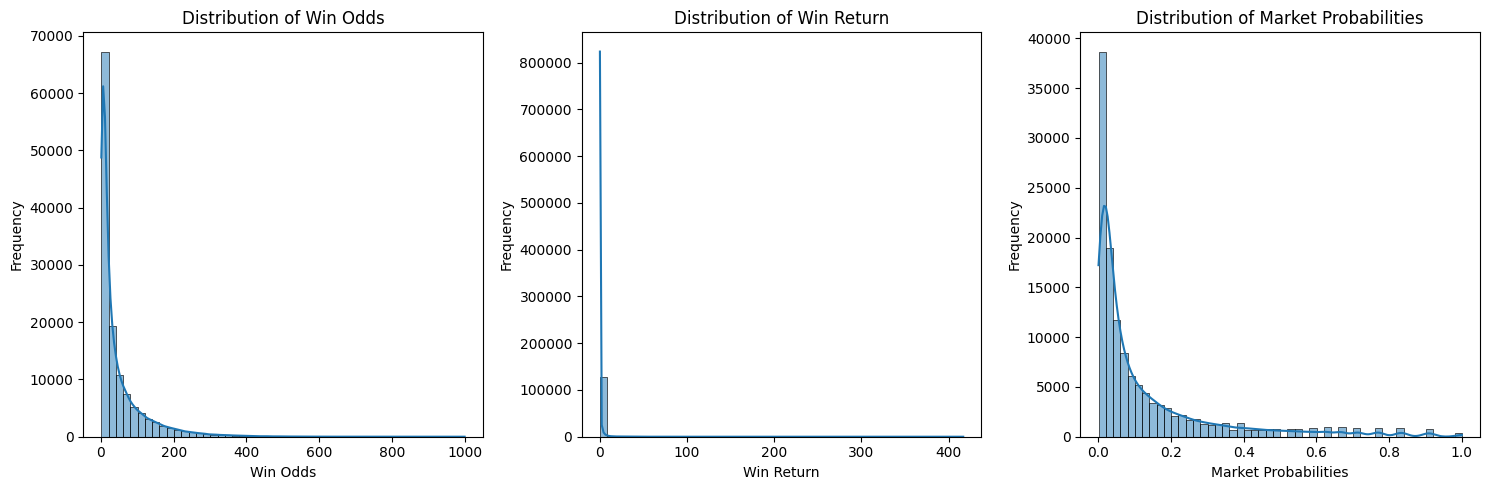

In [54]:
# 1. 1-variable distributions
plt.figure(figsize=(15, 5))

# distribution of win odds
plt.subplot(1, 3, 1)
sns.histplot(data_new['win_odds'], bins=50, kde=True)
plt.title('Distribution of Win Odds')
plt.xlabel('Win Odds')
plt.ylabel('Frequency')

# distribution of win return
plt.subplot(1, 3, 2)
sns.histplot(data_new['win_return'], bins=50, kde=True)
plt.title('Distribution of Win Return')
plt.xlabel('Win Return')
plt.ylabel('Frequency')

# distribution of market probabilities, for reference
plt.subplot(1, 3, 3)
sns.histplot(data_new['market_probs'], bins=50, kde=True)
plt.title('Distribution of Market Probabilities')
plt.xlabel('Market Probabilities')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Getting onto verifying our hypothesis, now it is time to test the effect of win odds on average win return. Before that, we observed that data is very skewed, but from data wrangling, we also observe that win return is less skewed on logarithmic scaled Odds. Therefore, we will use logarithmic scale for the x axes in both of the following plots.

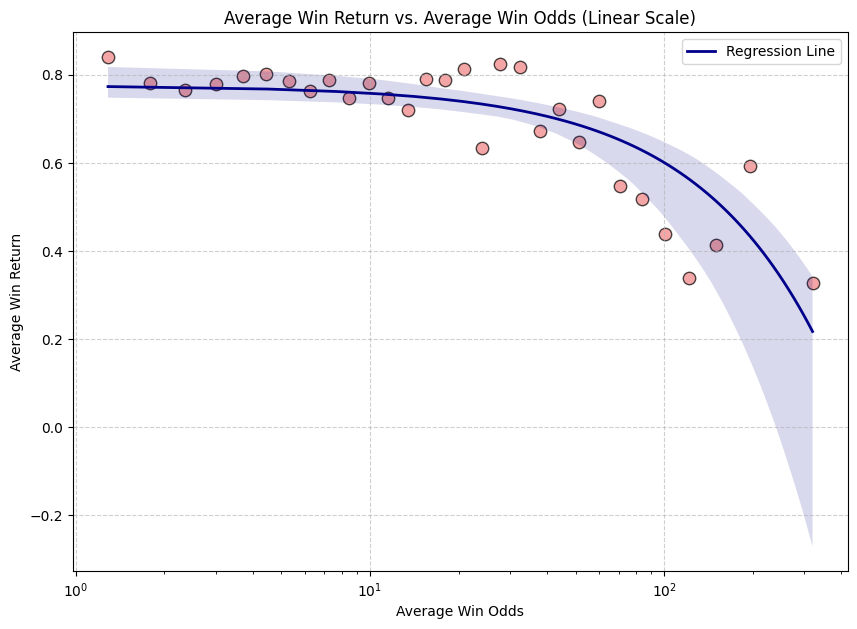

In [55]:
# 2. relationship visualization (linear with logarithmic x scale)
plt.figure(figsize=(10, 7))

# regression
sns.regplot(
    data=binned_odds_return, x='average_win_odds', y='average_win_return', ci=95,
    scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'black', 'color': 'lightcoral'},
    line_kws={'color': 'darkblue', 'linestyle': '-', 'lw': 2, 'label': 'Regression Line'}
)

# labels
plt.title('Average Win Return vs. Average Win Odds (Linear Scale)')
plt.xlabel('Average Win Odds')
plt.ylabel('Average Win Return')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


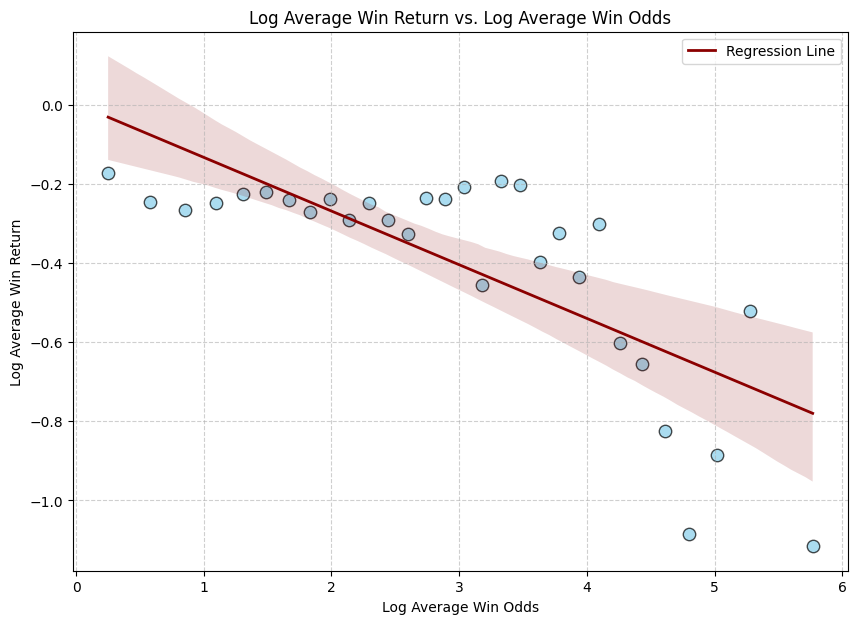

In [56]:
# 3. relationship visualization (log on both axes)
plt.figure(figsize=(10, 7))

# data processing is used instead of logged display
# since we want the confidence interval to also be on log scale.
# if we use log scaled axes for x and y, but confidence interval is linear,
# the shape of confidence interval is always leaning to negative side,
# resulting in a less suggestive visualization.
binned_odds_return['log_average_win_odds'] = np.log(binned_odds_return['average_win_odds'])
binned_odds_return['log_average_win_return'] = np.log(binned_odds_return['average_win_return'])

# regression
sns.regplot(
    data=binned_odds_return, x='log_average_win_odds', y='log_average_win_return', ci=95,
    scatter_kws={'s': 80, 'alpha': 0.7, 'edgecolor': 'black', 'color': 'skyblue'},
    line_kws={'color': 'darkred', 'linestyle': '-', 'lw': 2, 'label': 'Regression Line'}
)

# labels
plt.title('Log Average Win Return vs. Log Average Win Odds')
plt.xlabel('Log Average Win Odds')
plt.ylabel('Log Average Win Return')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - Our data did not include data related to human individuals.
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 - We collected continuous data in a period of 10 years without repetition or missing data on all races, preventing bias.
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - Our data did not include data related to human individuals.
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
 - Our data did not include data related to human individuals.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - We only used open sourced data.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - Our data did not include data related to human individuals.
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
 - We only used open sourced data.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [ ] The data is collected from a single racecourse (Saga Racecourse) and therefore does not represent all horse races across different regions. In addition, betting odds are market prices rather than natural probabilities, as betting companies may adjust odds to manage risk and avoid losses.
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [ ] The analysis focuses on aggregated group-level results, and we avoid discussing or highlighting individual horses or horse racers.
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
 - [ ] We clearly document how the data was obtained, the analytical steps taken, the conclusions drawn, and the formulas used.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] The model only uses race-related variables such as odds and outcomes and does not include or proxy any protected human attributes.
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] This project does not make decisions affecting human groups, so group-level fairness testing is not applicable.
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considering additional metrics?
 - [ ] We considered how different performance metrics (e.g., average return versus risk) may affect the interpretation of results.
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [ ] We will analyze using simple statistical summaries and explain them in clear, non-technical terms.
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] The model is not deployed in a real-world system and is only used for academic analysis, so ongoing monitoring is not required.
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] Since the analysis does not directly impact users or decision-making, a formal redress mechanism is not applicable.
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] The project does not involve a production system, so rollback mechanisms are unnecessary.
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
 - [ ] We clearly document how the data was obtained, the analytical steps taken, the conclusions drawn, and the formulas used.

## Team Expectations

* *Team Expectation 1*：**Timely communication and response.** Each team member must maintain regular communication. When other members have questions regarding the project, they must respond by 11:59 PM that same day. Additionally, team members are required to regularly report project progress in the group chat.
* *Team Expectation 2*：**Complete the corresponding tasks on time.** Each team member must complete their assigned portion within the specified timeframe. If unable to submit on time, promptly notify other team members in the group chat and discuss a new deadline.
* *Team Expectation 3*：**Active participation and discussion.** All team members are required to actively participate in project discussions and attend weekly team meetings punctually each time. If unable to attend, promptly notify the group chat. During discussions, everyone should actively voice their ideas or raise questions about specific matters.
* *Team Expectation 4*: **Mutual Respect and Cooperation.** Everyone should respect each other's work. We encourage the expression of differing viewpoints, but we do not tolerate vicious insults or accusations against other members. Discussions should be conducted rationally.
* *Team Expectation 5*: **Resolve conflicts.** When conflicts arise, we should first attempt to resolve them internally. If resolution proves impossible, promptly seek assistance from the relevant party or professor. We must address issues in a fair manner.

## Project Timeline Proposal


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 3/13  | 6 PM  | Complete analysis; Draft results/conclusion/discussion (Wasp)| Discuss/edit full project |
| 3/20  | Before 11:59 PM  | NA | Turn in Final Project & Group Project Surveys |